In [16]:
!pip install yellowbrick
import os
os.environ["OMP_NUM_THREADS"] = '2'
import numpy as np 
import pandas as pd
import pickle
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from IPython.display import display
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Defaulting to user installation because normal site-packages is not writeable


# Get File

In [17]:
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')

print(f"Ready for clustering with {X_train_scaled.shape[1]} features.")

Ready for clustering with 39 features.


# Create Visualiser for k-means

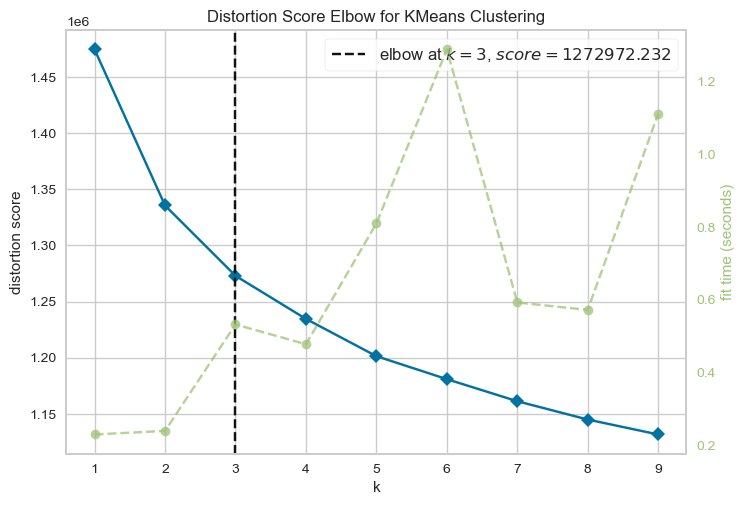

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))


visualizer.fit(X_train_scaled) 
visualizer.poof()

# Limit k-means to 19 features
This ensures efficiency for minimal loss in accuracy (or potential gain in leaving out "noise").

In [19]:
clinical_features = [
    'Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]


X_train_clinical = X_train_scaled[clinical_features]


kmeans_19 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_19.fit(X_train_clinical)

os.makedirs('../artifacts', exist_ok=True)
joblib.dump(kmeans_19, '../artifacts/kmeans_model.pkl')


['../artifacts/kmeans_model.pkl']

# Calculate distrobution and mean values for each cluster feature

In [20]:
clinical_features = [
    'Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]

clusters = kmeans_19.predict(X_train_scaled[clinical_features])

X_train['Cluster'] = clusters

print("=" * 50)
print("CLUSTER DISTRIBUTION")
print("=" * 50)
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = count / len(clusters) * 100
    print(f"Cluster {cluster}: {count:,} patients ({pct:.1f}%)")

print("\n" + "=" * 50)
print("CLUSTER PROFILES - Mean Values")
print("=" * 50)

key_features = [
    'Age', 'bmi', 'hba1c', 'glucose_fasting', 'glucose_postprandial',
    'physical_activity_minutes_per_week', 'diet_score', 'systolic_bp'
]

cluster_profile = X_train.groupby('Cluster')[key_features].mean()
cluster_profile['Patient_Count'] = cluster_counts
display(cluster_profile.round(2))

CLUSTER DISTRIBUTION
Cluster 0: 22,973 patients (34.5%)
Cluster 1: 20,498 patients (30.8%)
Cluster 2: 23,117 patients (34.7%)

CLUSTER PROFILES - Mean Values


,Age,bmi,hba1c,glucose_fasting,glucose_postprandial,physical_activity_minutes_per_week,diet_score,systolic_bp,Patient_Count
Cluster,,,,,,,,,
0,57.42,28.31,6.73,115.35,166.83,111.27,5.60,123.08,22973
1,48.61,24.13,7.09,118.25,181.44,106.10,6.15,112.99,20498
2,44.28,24.29,5.80,100.44,134.03,138.26,6.23,110.96,23117


# Scatter plots

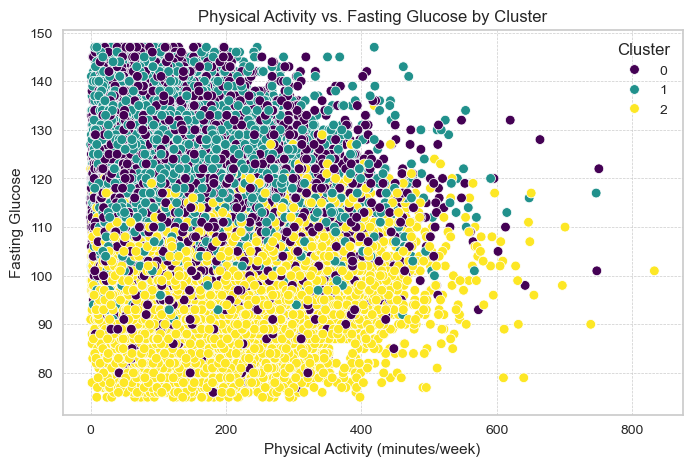

In [23]:
plt.figure(figsize=(8, 5))

# Using the exact names from your X_train.columns output
sns.scatterplot(
    data=X_train,
    x="physical_activity_minutes_per_week", 
    y="glucose_fasting", 
    hue="Cluster",
    palette="viridis"
)

plt.xlabel("Physical Activity (minutes/week)")
plt.ylabel("Fasting Glucose")
plt.title("Physical Activity vs. Fasting Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()


The scatter plot show clear seperation mainly by fasting glucose . cluster 1  has the highest glucose value (high-risk group) ,Cluster 0 has the lowest glucose values(low-risk group) , and Cluster 2 falls in between (moderate risk) . Physical activity overlaps across clusters ,meaning glucose is the strongest factor driving the segmentation 

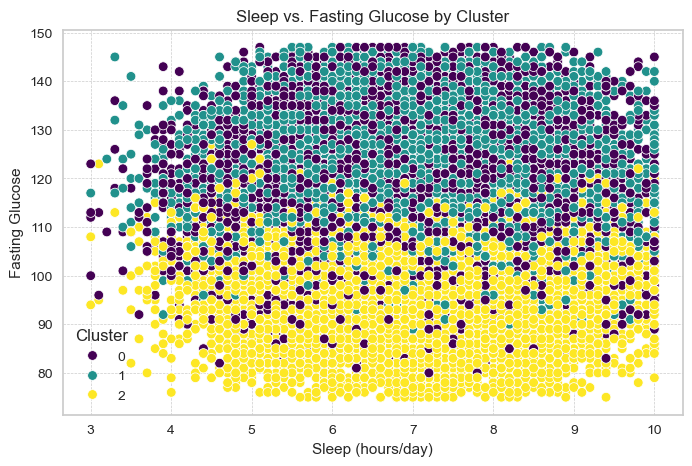

In [24]:
plt.figure(figsize=(8, 5))

# Using the exact names from your X_train output
sns.scatterplot(
    data=X_train,
    x="sleep_hours_per_day",
    y="glucose_fasting",
    hue="Cluster",
    palette="viridis"
)

plt.xlabel("Sleep (hours/day)")
plt.ylabel("Fasting Glucose")
plt.title("Sleep vs. Fasting Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Fasting glucose clearly seperates the clusters , while sleep hours overlap across all groups. Cluster 1 shows shows consistently higher glucose (high-risk),Cluster 0 lower glucose (low-risk),and Cluster 2 moderate levels . This suggests that sleep is not strong clustering factor compared to glucose

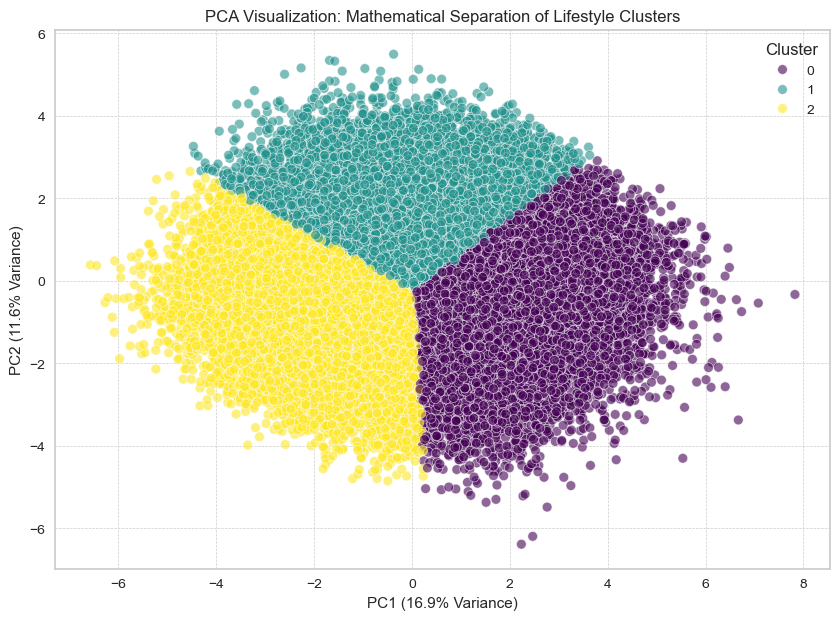

Total variance explained by 2 components: 28.5%
WHAT FEATURES DRIVE EACH COMPONENT?

 Top features driving PC1 (horizontal spread):
   bmi: patients with higher values → move RIGHT
   hba1c: patients with higher values → move RIGHT
   glucose_fasting: patients with higher values → move RIGHT
   ldl_cholesterol: patients with higher values → move RIGHT
   waist_to_hip_ratio: patients with higher values → move RIGHT

 Top features driving PC2 (vertical spread):
   hba1c: patients with higher values → move UP
   glucose_postprandial: patients with higher values → move UP
   glucose_fasting: patients with higher values → move UP
   ldl_cholesterol: patients with lower values → move UP
   bmi: patients with lower values → move UP

CLINICAL VALIDATION - Mean Values by Cluster
         hba1c  glucose_fasting    Age    bmi  \
Cluster                                         
0         6.73           115.35  57.42  28.31   
1         7.09           118.25  48.61  24.13   
2         5.80         

In [28]:
from sklearn.decomposition import PCA

X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')

clinical_features = [
    'Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]

clusters_scaled = kmeans_19.predict(X_train_scaled[clinical_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled[clinical_features])

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters_scaled

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Cluster", 
    palette="viridis", 
    alpha=0.6
)

plt.title("PCA Visualization: Mathematical Separation of Lifestyle Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

print("=" * 60)
print("WHAT FEATURES DRIVE EACH COMPONENT?")
print("=" * 60)

pca_components = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=clinical_features
)

print("\n Top features driving PC1 (horizontal spread):")
pc1_top = pca_components['PC1'].abs().sort_values(ascending=False).head(5)
for feature, weight in pc1_top.items():
    direction = "higher" if pca_components.loc[feature, 'PC1'] > 0 else "lower"
    print(f"   {feature}: patients with {direction} values → move RIGHT")

print("\n Top features driving PC2 (vertical spread):")
pc2_top = pca_components['PC2'].abs().sort_values(ascending=False).head(5)
for feature, weight in pc2_top.items():
    direction = "higher" if pca_components.loc[feature, 'PC2'] > 0 else "lower"
    print(f"   {feature}: patients with {direction} values → move UP")

print("\n" + "=" * 60)
print("CLINICAL VALIDATION - Mean Values by Cluster")
print("=" * 60)

key_metrics = ['hba1c', 'glucose_fasting', 'Age', 'bmi', 'physical_activity_minutes_per_week']
cluster_means = X_train.groupby('Cluster')[key_metrics].mean()

# Determine risk ordering
cluster_means['Risk_Level'] = cluster_means['hba1c'].rank().map({
    1: 'Low Risk', 
    2: 'Moderate Risk', 
    3: 'High Risk'
})

print(cluster_means.round(2))

The PCA scatter plot reduces the multi-dimensional dataset into two principal componenets PC1 and PC2 to make the clusters in two dimension . The plot shows three clearly seperated groups , confirming that K- means sucessfully segmented the patients into three distinct lifestyle/clinical risk profiles.Cluster 0 is seperated on the right side higher (PC1) , indicating a distinct patient group with similar characteristics . 
Cluster 1 appears on the top  (higher PC2 values) , showing another clearly diffirent patient segment .Cluster 2 is concentrated towards the left (lower PC1 values ), forming a third unique group